In [15]:
import keras
from keras import layers
from keras.models import Model
import numpy as np

# [Note: Make sure your dataset is loaded properly above this line]
# (x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# 2. Make Normalization
# Convert pixel values to floats and scale them between 0 and 1
# This ensures stable and fast gradient updates during training
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# 3. Reshape the data into 784 bit (flatten 28x28 images)
# Flatten the 2D image matrix into a 1D vector of 784 numbers
# This is required because standard Dense layers only accept 1D inputs
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

# 4. Build the Auto encoding model with new architecture
# Define the input placeholder shape (784 features)
input_img = keras.Input(shape=(784,))

# Encoder: Gradually compresses the features from 784 -> 128 -> 64 -> 32 nodes
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded) # The Bottleneck layer (compressed representation)

# Decoder: Reconstructs the data back from 32 -> 64 -> 128 -> 784 nodes
decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
# Sigmoid activation outputs values between 0 and 1, matching our normalized inputs
decoded = layers.Dense(784, activation='sigmoid')(decoded)

# The full Autoencoder model that maps an input to its reconstructed output
autoencoder = Model(input_img, decoded)

# Separate Encoder model to extract the 32-dimensional latent code if needed
encoder = Model(input_img, encoded)

# Build the separate Decoder model structure for dedicated predictions later
encoded_input = keras.Input(shape=(32,))
x = layers.Dense(64, activation='relu')(encoded_input)
x = layers.Dense(128, activation='relu')(x)
decoder_output = layers.Dense(784, activation='sigmoid')(x)
decoder = Model(encoded_input, decoder_output)


# Compile our autoencoder
# Added 'binary_accuracy' metric to explicitly compute the reconstruction performance per epoch
autoencoder.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['binary_accuracy'])

# 5. Train the model
# We pass x_train as both input and target because the model is learning to replicate itself
history = autoencoder.fit(x_train, x_train,
                          epochs=20,
                          batch_size=256,
                          shuffle=True,
                          validation_data=(x_test, x_test))

# Print evaluation (reconstruction loss and accuracy)
# Evaluate returns both the final loss value and the accuracy value for the test dataset
loss, accuracy = autoencoder.evaluate(x_test, x_test, verbose=0)

# Display final performance metrics clearly in percentage format
print("\n" + "="*40)
print(f"Test Reconstruction Loss (BCE): {loss:.4f}")
print(f"Test Reconstruction Accuracy:   {accuracy * 100:.2f}%")
print("="*40 + "\n")

# Generate encoded compressions and reconstructed images for later plotting or analysis
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

x_train shape: (60000, 784)
x_test shape: (10000, 784)
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - binary_accuracy: 0.8057 - loss: 0.1010 - val_binary_accuracy: 0.8072 - val_loss: 0.0041
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.8088 - loss: 0.0041 - val_binary_accuracy: 0.8072 - val_loss: 0.0041
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8088 - loss: 0.0041 - val_binary_accuracy: 0.8072 - val_loss: 0.0041
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8088 - loss: 0.0040 - val_binary_accuracy: 0.8072 - val_loss: 0.0041
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8088 - loss: 0.0040 - val_binary_accuracy: 0.8072 - val_loss: 0.0040
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8088 - loss: 0.0039 - val_binary_accuracy: 0.8072 - val_loss: 0.0040
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8088 - loss: 0.0039

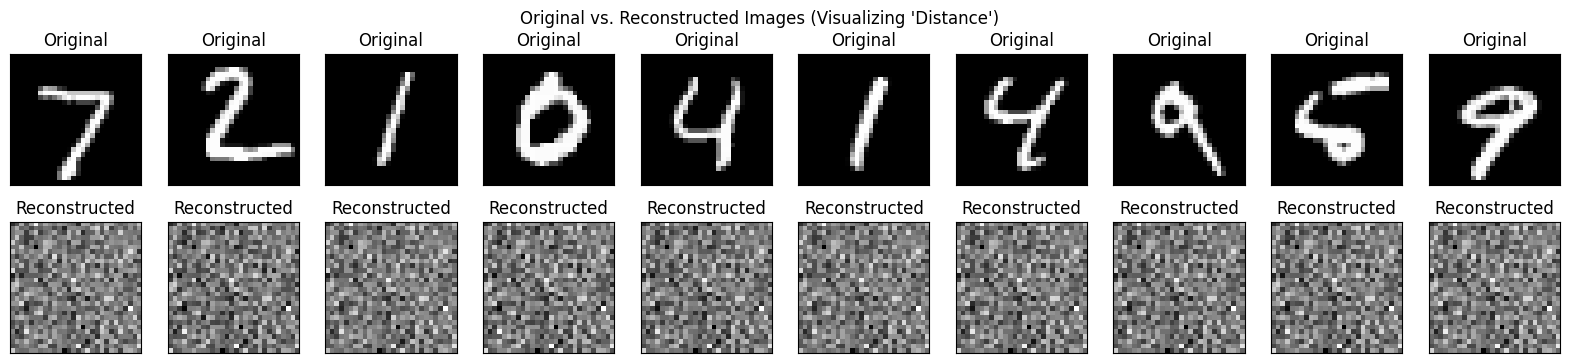

In [17]:
import matplotlib.pyplot as plt

# How many digits we will display
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.set_title("Original")

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.set_title("Reconstructed")
plt.suptitle("Original vs. Reconstructed Images (Visualizing 'Distance')")
plt.show()

# The numerical 'distance' between encoded and original (reconstruction error)
# is often quantified by metrics like Mean Squared Error (MSE) or binary cross-entropy loss.
# We have already calculated the MSE:
# import numpy as np
# mse = np.mean(np.power(x_test - decoded_imgs, 2))
# print(f"Test Mean Squared Error (MSE): {mse:.4f}")

In [19]:
import numpy as np

# Ensure decoded_imgs and x_test are available from previous cells
# If not, you might need to re-run the autoencoder training cell (FLDEzKNbchim)
# and then encoder.predict(x_test) and decoder.predict(encoded_imgs)

# Calculate Binary Cross-Entropy (BCE) for each individual image
# Using a small epsilon to avoid log(0) issues
epsilon = 1e-7
bce_per_pixel = -(x_test * np.log(decoded_imgs + epsilon) + (1 - x_test) * np.log(1 - decoded_imgs + epsilon))
bce_per_image = np.mean(bce_per_pixel, axis=1) # Average BCE over the 784 pixels for each image

print("Reconstruction Binary Cross-Entropy (BCE) for individual test images (first 10 samples):")
for i in range(10):
    print(f"Image {i+1}: {bce_per_image[i]:.4f}")

print(f"\nAverage BCE across all test images: {np.mean(bce_per_image):.4f}")
print(f"Minimum BCE: {np.min(bce_per_image):.4f}")
print(f"Maximum BCE: {np.max(bce_per_image):.4f}")
print(f"Standard Deviation of BCE: {np.std(bce_per_image):.4f}")

Reconstruction Binary Cross-Entropy (BCE) for individual test images (first 10 samples):
Image 1: 0.6972
Image 2: 0.6966
Image 3: 0.6971
Image 4: 0.6970
Image 5: 0.6972
Image 6: 0.6972
Image 7: 0.6972
Image 8: 0.6972
Image 9: 0.6972
Image 10: 0.6975

Average BCE across all test images: 0.6972
Minimum BCE: 0.6964
Maximum BCE: 0.6978
Standard Deviation of BCE: 0.0002
